In [2]:
from google.colab import files
uploaded = files.upload()

Saving Chocolate_Sales (2).csv to Chocolate_Sales (2).csv


In [7]:
import pandas as pd

df = pd.read_csv("Chocolate_Sales (2).csv")

print("First 5 rows:")
print(df.head())

print("\nData types before cleaning:")
print(df.dtypes)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)

df['Amount'] = pd.to_numeric(df['Amount'])

print("\nData types after cleaning:")
print(df.dtypes)

First 5 rows:
     Sales Person    Country              Product        Date      Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04/01/2022   $5,320.00   
1     Van Tuxwell      India        85% Dark Bars  01/08/2022   $7,896.00   
2    Gigi Bohling      India  Peanut Butter Cubes  07/07/2022   $4,501.00   
3    Jan Morforth  Australia  Peanut Butter Cubes  27/04/2022  $12,726.00   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24/02/2022  $13,685.00   

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  

Data types before cleaning:
Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

Data types after cleaning:
Sales Person             object
Country                  object
Product                  object
Date             datetime64[ns]
Amount                  float64
Boxes Shipped             int64
dt

In [8]:

import numpy as np

df2 = df.copy()

df2.loc[0:5, 'Amount'] = np.nan

print("Missing values before handling:")
print(df2.isna().sum())

df2['Amount'].fillna(df2['Amount'].median(), inplace=True)

print("\nMissing values after handling:")
print(df2.isna().sum())

Missing values before handling:
Sales Person     0
Country          0
Product          0
Date             0
Amount           6
Boxes Shipped    0
dtype: int64

Missing values after handling:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


/tmp/ipykernel_827/1025255280.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['Amount'].fillna(df2['Amount'].median(), inplace=True)


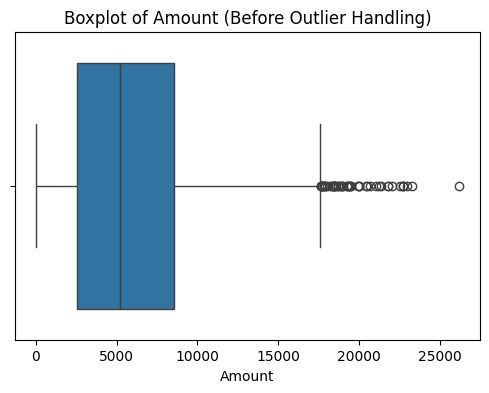

Number of outliers detected: 50
       Sales Person      Country              Product       Date   Amount  \
66      Van Tuxwell    Australia  Organic Choco Syrup 2022-08-10  19453.0   
135     Van Tuxwell        India  Organic Choco Syrup 2022-05-16  19929.0   
212  Marney O'Breen           UK   Smooth Sliky Salty 2022-05-13  18991.0   
434    Jan Morforth  New Zealand      Mint Chip Choco 2022-06-30  18340.0   
543    Ches Bonnell        India  Peanut Butter Cubes 2022-01-27  22050.0   

     Boxes Shipped  
66              14  
135            174  
212             88  
434            285  
543            208  
Dataset shape before removing outliers: (3282, 6)
Dataset shape after removing outliers: (3232, 6)


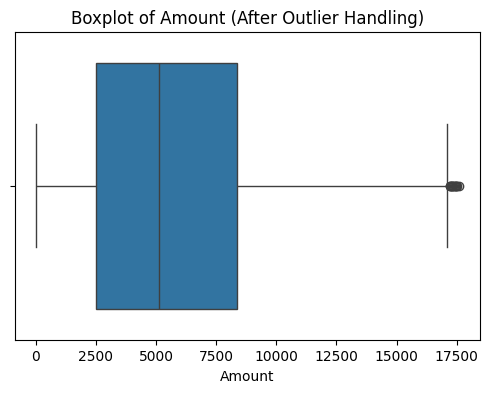

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df3 = df.copy()

plt.figure(figsize=(6,4))
sns.boxplot(x=df3['Amount'])
plt.title('Boxplot of Amount (Before Outlier Handling)')
plt.show()

Q1 = df3['Amount'].quantile(0.25)
Q3 = df3['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df3[(df3['Amount'] < lower_bound) | (df3['Amount'] > upper_bound)]
print("Number of outliers detected:", outliers.shape[0])
print(outliers.head())

df_no_outliers = df3[(df3['Amount'] >= lower_bound) & (df3['Amount'] <= upper_bound)]
print("Dataset shape before removing outliers:", df3.shape)
print("Dataset shape after removing outliers:", df_no_outliers.shape)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_no_outliers['Amount'])
plt.title('Boxplot of Amount (After Outlier Handling)')
plt.show()

First 5 rows after Min-Max Normalization:
     Sales Person    Country              Product       Date    Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco 2022-01-04  0.302267   
1     Van Tuxwell      India        85% Dark Bars 2022-08-01  0.448821   
2    Gigi Bohling      India  Peanut Butter Cubes 2022-07-07  0.255673   
3    Jan Morforth  Australia  Peanut Butter Cubes 2022-04-27  0.723610   
4  Jehu Rudeforth         UK  Peanut Butter Cubes 2022-02-24  0.778169   

   Boxes Shipped  
0       0.230373  
1       0.119691  
2       0.115830  
3       0.438867  
4       0.235521  


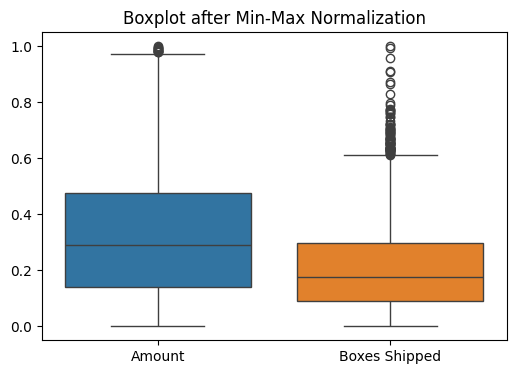

First 5 rows after Z-Score Normalization:
     Sales Person    Country              Product       Date    Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco 2022-01-04 -0.122284   
1     Van Tuxwell      India        85% Dark Bars 2022-08-01  0.510267   
2    Gigi Bohling      India  Peanut Butter Cubes 2022-07-07 -0.323394   
3    Jan Morforth  Australia  Peanut Butter Cubes 2022-04-27  1.696301   
4  Jehu Rudeforth         UK  Peanut Butter Cubes 2022-02-24  1.931789   

   Boxes Shipped  
0       0.121823  
1      -0.569696  
2      -0.593819  
3       1.424452  
4       0.153987  


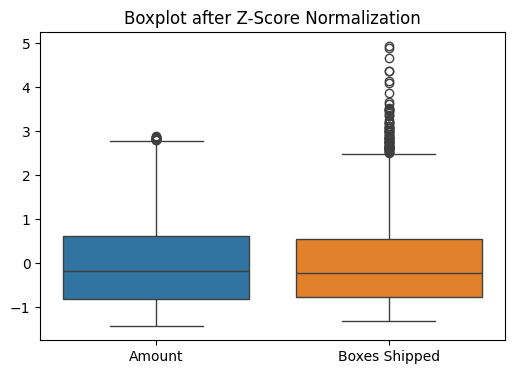

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df_minmax = df_no_outliers.copy()
scaler = MinMaxScaler()
df_minmax[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_minmax[['Amount', 'Boxes Shipped']])
print("First 5 rows after Min-Max Normalization:")
print(df_minmax.head())

plt.figure(figsize=(6,4))
sns.boxplot(data=df_minmax[['Amount', 'Boxes Shipped']])
plt.title("Boxplot after Min-Max Normalization")
plt.show()

df_zscore = df_no_outliers.copy()
scaler = StandardScaler()
df_zscore[['Amount', 'Boxes Shipped']] = scaler.fit_transform(df_zscore[['Amount', 'Boxes Shipped']])
print("First 5 rows after Z-Score Normalization:")
print(df_zscore.head())

plt.figure(figsize=(6,4))
sns.boxplot(data=df_zscore[['Amount', 'Boxes Shipped']])
plt.title("Boxplot after Z-Score Normalization")
plt.show()

Explained Variance Ratio: [0.50454018 0.49545982]


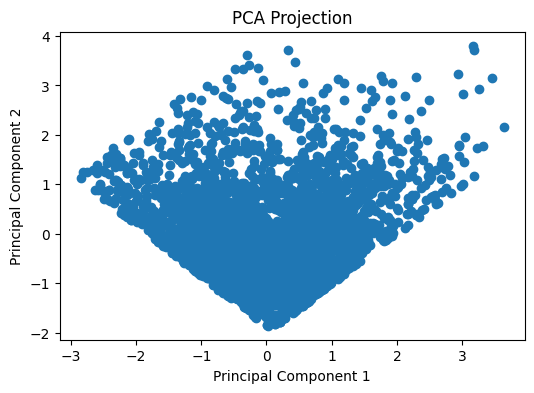

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df_zscore[['Amount', 'Boxes Shipped']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()